In [102]:
import numpy as np
import pandas
from matplotlib import pyplot as plt
from scipy.spatial.transform import Rotation as R3D

In [103]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import pycamcal

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [104]:
DATASET_DIR = "./synthetic_calibration_example"
DETECTIONS_DIR = f"{DATASET_DIR}/results/target_detection"
RESULTS_DIR = f"{DATASET_DIR}/results/calibration/"

## Load Calibration Data

In [105]:
from pycamcal.calibration.targets.checkerboard import CheckerboardTarget
from pycamcal.primitives.pose import Pose3D, R3D

import json

# load calibration target info
with open(f"{DATASET_DIR}/dataset/calibration_target_info.json") as f:
    calibration_target_info = json.load(f)

# compose world-space target feature points
target = CheckerboardTarget(**calibration_target_info["params"])
target_pose = Pose3D(
    calibration_target_info["pose"]["position"],
    R3D.from_quat(calibration_target_info["pose"]["orientation"])
)

calibration_target_points = target.get_object_points(target_pose)
calibration_target_points

{'CB-0-0': array([-1.   ,  2.125,  2.5  ]),
 'CB-0-1': array([-0.75 ,  2.125,  2.5  ]),
 'CB-0-2': array([-0.5  ,  2.125,  2.5  ]),
 'CB-0-3': array([-0.25 ,  2.125,  2.5  ]),
 'CB-0-4': array([0.   , 2.125, 2.5  ]),
 'CB-0-5': array([0.25 , 2.125, 2.5  ]),
 'CB-0-6': array([0.5  , 2.125, 2.5  ]),
 'CB-0-7': array([0.75 , 2.125, 2.5  ]),
 'CB-0-8': array([1.   , 2.125, 2.5  ]),
 'CB-1-0': array([-1.   ,  2.125,  2.25 ]),
 'CB-1-1': array([-0.75 ,  2.125,  2.25 ]),
 'CB-1-2': array([-0.5  ,  2.125,  2.25 ]),
 'CB-1-3': array([-0.25 ,  2.125,  2.25 ]),
 'CB-1-4': array([0.   , 2.125, 2.25 ]),
 'CB-1-5': array([0.25 , 2.125, 2.25 ]),
 'CB-1-6': array([0.5  , 2.125, 2.25 ]),
 'CB-1-7': array([0.75 , 2.125, 2.25 ]),
 'CB-1-8': array([1.   , 2.125, 2.25 ]),
 'CB-2-0': array([-1.   ,  2.125,  2.   ]),
 'CB-2-1': array([-0.75 ,  2.125,  2.   ]),
 'CB-2-2': array([-0.5  ,  2.125,  2.   ]),
 'CB-2-3': array([-0.25 ,  2.125,  2.   ]),
 'CB-2-4': array([0.   , 2.125, 2.   ]),
 'CB-2-5': array([0.2

In [106]:
from pycamcal.calibration.calibration_problem import ImageCaptureObservations

# load calibration target detection results
target_detections_df = pandas.read_csv(f"{DETECTIONS_DIR}/target_feature_detections.csv", index_col="img_fname")

feature_ids = sorted(set(col.split(".")[0] for col in target_detections_df.columns))

# img_fname -> observations
image_observations = {}

for img_fname, row in target_detections_df.iterrows():
    observations = ImageCaptureObservations({
        feature_id: np.array([row[f"{feature_id}.x"], row[f"{feature_id}.y"]])
        for feature_id in feature_ids
    })

    image_observations[img_fname] = observations

image_observations

{'image_000.png': ImageCaptureObservations(feature_detections={'CB-0-0': array([329.622, 290.359]), 'CB-0-1': array([374.802, 292.413]), 'CB-0-2': array([419.383, 294.862]), 'CB-0-3': array([462.572, 297.619]), 'CB-0-4': array([504.85 , 300.673]), 'CB-0-5': array([545.607, 303.958]), 'CB-0-6': array([585.226, 307.344]), 'CB-0-7': array([623.239, 310.826]), 'CB-0-8': array([659.499, 314.475]), 'CB-1-0': array([327.655, 337.361]), 'CB-1-1': array([373.411, 338.707]), 'CB-1-2': array([418.073, 340.618]), 'CB-1-3': array([461.684, 342.683]), 'CB-1-4': array([504.254, 344.986]), 'CB-1-5': array([545.176, 347.535]), 'CB-1-6': array([584.741, 350.205]), 'CB-1-7': array([623.244, 352.87 ]), 'CB-1-8': array([659.767, 355.678]), 'CB-2-0': array([326.324, 385.217]), 'CB-2-1': array([372.125, 386.055]), 'CB-2-2': array([417.247, 387.365]), 'CB-2-3': array([461.004, 388.582]), 'CB-2-4': array([503.616, 390.237]), 'CB-2-5': array([544.769, 391.751]), 'CB-2-6': array([584.761, 393.65 ]), 'CB-2-7': ar

In [107]:
from pycamcal.primitives.pose import Pose3D, R3D

camera_poses_truth = {}

poses_df = pandas.read_csv(f"{DATASET_DIR}/dataset/true_camera_poses.csv", index_col="img_fname")

for img_fname, row in poses_df.iterrows():
    pos = row[["x", "y", "z"]].to_numpy()
    att = R3D.from_quat(row[["qx", "qy", "qz", "qw"]])

    camera_poses_truth[img_fname] = Pose3D(pos, att)

camera_poses_truth

{'image_000.png': Pose3D(t=array([-1.33266182, -2.38742167,  1.47938199]), R=<scipy.spatial.transform._rotation.Rotation object at 0x31cf0dd40>),
 'image_001.png': Pose3D(t=array([-0.22782543, -1.96539859,  2.58460697]), R=<scipy.spatial.transform._rotation.Rotation object at 0x31cf0df20>),
 'image_002.png': Pose3D(t=array([-1.33311962, -0.26217826,  3.57094694]), R=<scipy.spatial.transform._rotation.Rotation object at 0x31cf0e010>),
 'image_003.png': Pose3D(t=array([-2.15446433, -1.79568482,  3.09110543]), R=<scipy.spatial.transform._rotation.Rotation object at 0x31cf0e100>),
 'image_004.png': Pose3D(t=array([-2.09967561, -0.24277363,  2.2388344 ]), R=<scipy.spatial.transform._rotation.Rotation object at 0x31cf0e1f0>),
 'image_005.png': Pose3D(t=array([ 1.62152671, -0.7352917 ,  1.86180323]), R=<scipy.spatial.transform._rotation.Rotation object at 0x31cf0e2e0>),
 'image_006.png': Pose3D(t=array([-0.46981794, -1.28092887,  3.69679016]), R=<scipy.spatial.transform._rotation.Rotation obj

## Define Calibration Problem

In [108]:
from pycamcal.calibration import CalibrationProblem
from pycamcal.optimization import Fixed, Unknown

calib = CalibrationProblem()

In [109]:
from pycamcal.camera_model import CameraModel, RadialTangentialDistortion

# Define the type of camera model to be fit, with known values/initial guesses filled in.

cmod = CameraModel(
    res_xy=(1200, 1000),

    # fixed known pinhole params
    fx=Fixed(825.829),
    fy=Fixed(866.025),
    cx=Fixed(600),
    cy=Fixed(500),

    # unknown distortion (with inital guess)
    distortion=RadialTangentialDistortion(
        k1=Unknown(initial=-0.20),
        k2=Unknown(initial=+0.00),
        k3=Unknown(initial=+0.00),
        p1=Unknown(initial=+0.00),
        p2=Unknown(initial=+0.00)
    )
)

calib.add_camera("CAM_001", cmod)

In [110]:
# Add the known calibration target geometry

calib.add_known_scene_points(calibration_target_points)

In [111]:
# Add the observed feature locations

for image_id, observations in image_observations.items():
    # # unsurveyed (camera poses unknown)
    # calib.add_observations("CAM_001", image_id, observations, camera_pose=None)

    # surveyed (camera poses known)
    calib.add_observations("CAM_001", image_id, observations, camera_pose=Fixed(camera_poses_truth[image_id]))

In [112]:
print(calib)

CalibrationProblem(cameras={'CAM_001': <pycamcal.camera_model.camera_model.CameraModel object at 0x31c9d0430>}, scene_points={'CB-0-0': Fixed([-1.     2.125  2.5  ]), 'CB-0-1': Fixed([-0.75   2.125  2.5  ]), 'CB-0-2': Fixed([-0.5    2.125  2.5  ]), 'CB-0-3': Fixed([-0.25   2.125  2.5  ]), 'CB-0-4': Fixed([0.    2.125 2.5  ]), 'CB-0-5': Fixed([0.25  2.125 2.5  ]), 'CB-0-6': Fixed([0.5   2.125 2.5  ]), 'CB-0-7': Fixed([0.75  2.125 2.5  ]), 'CB-0-8': Fixed([1.    2.125 2.5  ]), 'CB-1-0': Fixed([-1.     2.125  2.25 ]), 'CB-1-1': Fixed([-0.75   2.125  2.25 ]), 'CB-1-2': Fixed([-0.5    2.125  2.25 ]), 'CB-1-3': Fixed([-0.25   2.125  2.25 ]), 'CB-1-4': Fixed([0.    2.125 2.25 ]), 'CB-1-5': Fixed([0.25  2.125 2.25 ]), 'CB-1-6': Fixed([0.5   2.125 2.25 ]), 'CB-1-7': Fixed([0.75  2.125 2.25 ]), 'CB-1-8': Fixed([1.    2.125 2.25 ]), 'CB-2-0': Fixed([-1.     2.125  2.   ]), 'CB-2-1': Fixed([-0.75   2.125  2.   ]), 'CB-2-2': Fixed([-0.5    2.125  2.   ]), 'CB-2-3': Fixed([-0.25   2.125  2.   ]), 'C

## Solve

In [113]:
calib.collect_unknowns()

[Unknown(current=-0.2),
 Unknown(current=0.0),
 Unknown(current=0.0),
 Unknown(current=0.0),
 Unknown(current=0.0)]

[329.622 290.359] [326.5773  286.42587]


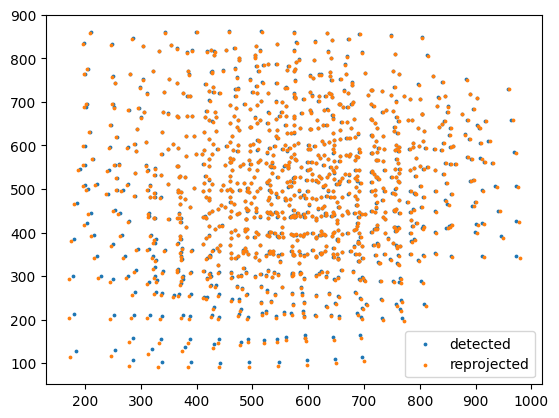

In [114]:
features_detected, featured_reprojected = calib.get_reprojections()

print(features_detected[0], featured_reprojected[0])

plt.scatter(features_detected[:,0],    features_detected[:,1],    s=3.0, label="detected")
plt.scatter(featured_reprojected[:,0], featured_reprojected[:,1], s=3.0, label="reprojected")

plt.legend()

diff(detect=[[329.622 290.359]
 [374.802 292.413]
 [419.383 294.862]
 ...
 [850.265 689.699]
 [901.602 709.255]
 [958.074 730.468]], reproj=[[326.5773  286.42587]
 [372.7608  289.2531 ]
 [417.92603 292.32098]
 ...
 [851.1588  689.297  ]
 [903.1682  708.6267 ]
 [960.4074  729.5812 ]])


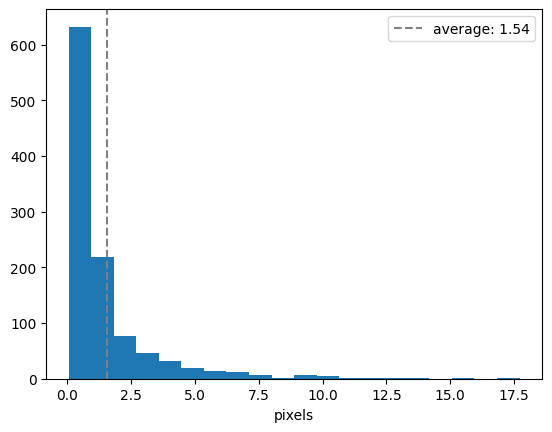

In [115]:
residuals = calib.get_residuals()

residuals_avg = np.mean(residuals)

plt.hist(residuals, bins=20)
plt.axvline(residuals_avg, linestyle="--", color="gray", label=f"average: {residuals_avg:.2f}")
plt.xlabel("pixels")

plt.legend()